In [17]:
from tiff_filter.filter_tiff import TiffFilter

In [18]:
tf = TiffFilter(tiff_path="../data/", out_path="./out")

1. filtering by threshold i.e. all values over 80% are saved 

2. identify large structures i.e. large areas of noise and remove them 

3. these are then saved as "unfiltered.npz" (1) and "filtered.npz" (2) _sparse_ arrays (identifies where nonzero elements are making it less memory intensive)

In [19]:
tf.run(
    init_threshold=0.8, area_threshold=5000,footprint=(40,40)
    )

# these are saved as "sparse" numpy arrays (only tells the lo)

  0%|          | 0/2 [00:00<?, ?it/s]

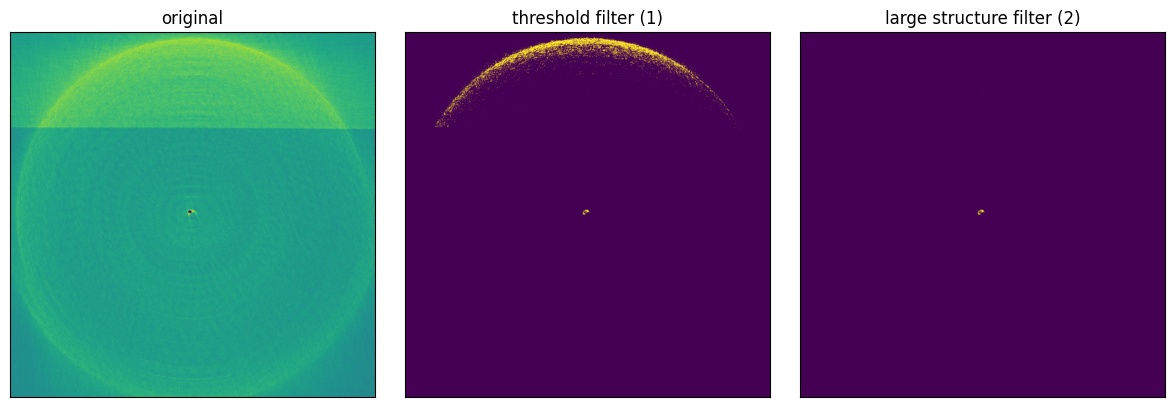

In [20]:
import matplotlib.pyplot as plt 
import rasterio 
import sparse 

fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,4),dpi=100)

original = rasterio.open("../data/037_PP-TPE_23_h_0001_0000pag_db0100_vol_000060.tiff").read()[0]
filter_1 = sparse.load_npz(tf.out_path+"/sparse_unfiltered_037_PP-TPE_23_h_0001_0000pag_db0100_vol_000060.npz").todense()
filter_2 = sparse.load_npz(tf.out_path+"/sparse_filtered_037_PP-TPE_23_h_0001_0000pag_db0100_vol_000060.npz").todense()
ax1.imshow(original)
ax2.imshow(filter_1)
ax3.imshow(filter_2)

ax1.set_title("original")
ax2.set_title("threshold filter (1)")
ax3.set_title("large structure filter (2)")

[ax.set_xticks([]) for ax in [ax1,ax2,ax3]]
[ax.set_yticks([]) for ax in [ax1,ax2,ax3]]

plt.tight_layout()
plt.show()

In [21]:
# you can join the individual .npz files together into one volume 
tf.join_data(volume=0,filtered=True) 

In [22]:
total = sparse.load_npz("total_0_sparse_filtered.npz")

total

Format,coo
Data Type,uint16
Shape,"(2, 2016, 2016)"
nnz,775
Density,9.534340356512976e-05
Read-only,True
Size,19.7K
Storage ratio,0.00


In [1]:
from tiff_filter.point_cloud import PointCloudGenerator

In [2]:
pcg = PointCloudGenerator(location="./")

In [5]:
pcd = pcg.create_point_cloud(volume=0,filtered=True)
pcd

PointCloud with 775 points.

In [6]:
pcg.write_point_cloud(pcd,"point_cloud_0.pcd")

point cloud written to point_cloud_0.pcd


In [8]:
denoised_pcd = pcg.general_denoise(pcd)
denoised_pcd

PointCloud with 756 points.

In [10]:
tree_pcd = pcg.find_tree(denoised_pcd)
tree_pcd

point cloud has 1 clustersPrecompute neighbors.[=>                                      ] 2%
Precompute neighbors.[========================================] 100%
Clustering[========================================] 100%


PointCloud with 756 points.

In [11]:
pcg.write_point_cloud(tree_pcd,"tree_pcd.pcd")

point cloud written to tree_pcd.pcd


this can then be opened in open3d with 


```
open3d draw tree_pcd.pcd 
```

or in plotly (slower for very large point clouds)

(2, 2016, 2016)

In [26]:
import open3d as o3d
import plotly.express as px
import pandas as pd
import numpy as np

# 1. Read the PCD file
# 2. Convert to numpy array

shape = sparse.load_npz("total_0_sparse_filtered.npz").shape # just to get the bounding box
points = np.asarray(tree_pcd.points)

# 3. Create a DataFrame
df = pd.DataFrame(points, columns=['x', 'y', 'z'])

# 4. Plot with Plotly
fig = px.scatter_3d(df, x='x', y='y', z='z', opacity=0.5)
fig.update_traces(marker=dict(size=2)) # Adjust marker size

fig.update_layout(
        scene=dict(
            xaxis=dict(range=[0, 2016], autorange=False),#
            yaxis=dict(range=[0, shape[1]], autorange=False),
            zaxis=dict(range=[0, shape[2]], autorange=False),
            aspectmode='cube' # Forces the plot to be a perfect cube
        ),
        uirevision='constant' # Keeps camera position while sliding
    )

fig.show()